<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/TY-open-elective/Assingments/8_Car_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 8**

Recommendation Category Classification using K-NN - Use K NN to classify . Experiment with different values of K and distance metrics . i want to perform this assignment so suggest me some dataset along with dataset link

Car Evaluation

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elikplim/car-evaluation-data-set")

print("Path to dataset files:", path)

100%|██████████| 4.66k/4.66k [00:00<00:00, 6.12MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/car-evaluation-data-set/versions/1


In [2]:
import os
import pandas as pd

# List files in the dataset directory
print(os.listdir(path))

['car_evaluation.csv']


In [3]:
csv_path = os.path.join(path, "car_evaluation.csv")
df = pd.read_csv(csv_path)

df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 10 rows:")
display(df.head(10))

Shape: (1727, 7)

Columns:
Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')

First 10 rows:


,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
5,vhigh,vhigh,2,2,big,low,unacc
6,vhigh,vhigh,2,2,big,med,unacc
7,vhigh,vhigh,2,2,big,high,unacc
8,vhigh,vhigh,2,4,small,low,unacc
9,vhigh,vhigh,2,4,small,med,unacc


In [5]:
df.columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

display(df.head())

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [6]:
print(df.info())

print("\nUnique values in each column:\n")

for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")
    print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None

Unique values in each column:

buying: ['vhigh' 'high' 'med' 'low']

maint: ['vhigh' 'high' 'med' 'low']

doors: ['2' '3' '4' '5more']

persons: ['2' '4' 'more']

lug_boot: ['small' 'med' 'big']

safety: ['med' 'high' 'low']

class: ['unacc' 'acc' 'vgood' 'good']



class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


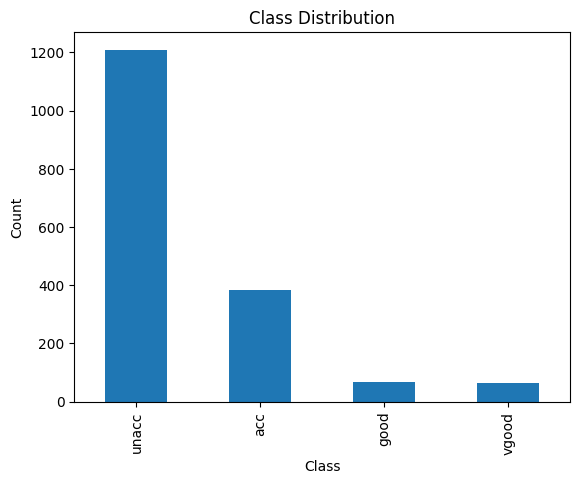

In [7]:
print(df['class'].value_counts())

import matplotlib.pyplot as plt

df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

display(df.head())

print("\nEncoded Class Mapping:")
for original, encoded in zip(
    encoders['class'].classes_,
    range(len(encoders['class'].classes_))
):
    print(f"{original} -> {encoded}")

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2



Encoded Class Mapping:
acc -> 0
good -> 1
unacc -> 2
vgood -> 3


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1381, 6)
X_test shape : (346, 6)
y_train shape: (1381,)
y_test shape : (346,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

print("\nFirst scaled row:")
print(X_train_scaled[0])

X_train_scaled shape: (1381, 6)
X_test_scaled shape : (346, 6)

First scaled row:
[ 0.44579358  0.47138492 -0.42463237 -0.00793751  0.01155289  1.21966489]


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9624277456647399

Confusion Matrix:
[[ 74   0   3   0]
 [  6   8   0   0]
 [  1   0 241   0]
 [  2   1   0  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        77
           1       0.89      0.57      0.70        14
           2       0.99      1.00      0.99       242
           3       1.00      0.77      0.87        13

    accuracy                           0.96       346
   macro avg       0.94      0.82      0.87       346
weighted avg       0.96      0.96      0.96       346



In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

results = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results.append(accuracy)

    print(f"K = {k:2d}  --> Accuracy = {accuracy:.4f}")

# Find best K
best_k = k_values[results.index(max(results))]
best_accuracy = max(results)

print("\nBest K:", best_k)
print("Best Accuracy:", best_accuracy)

K =  1  --> Accuracy = 0.7197
K =  3  --> Accuracy = 0.9364
K =  5  --> Accuracy = 0.9624
K =  7  --> Accuracy = 0.9422
K =  9  --> Accuracy = 0.9191
K = 11  --> Accuracy = 0.9046
K = 13  --> Accuracy = 0.9104
K = 15  --> Accuracy = 0.9075
K = 17  --> Accuracy = 0.9133
K = 19  --> Accuracy = 0.9046

Best K: 5
Best Accuracy: 0.9624277456647399


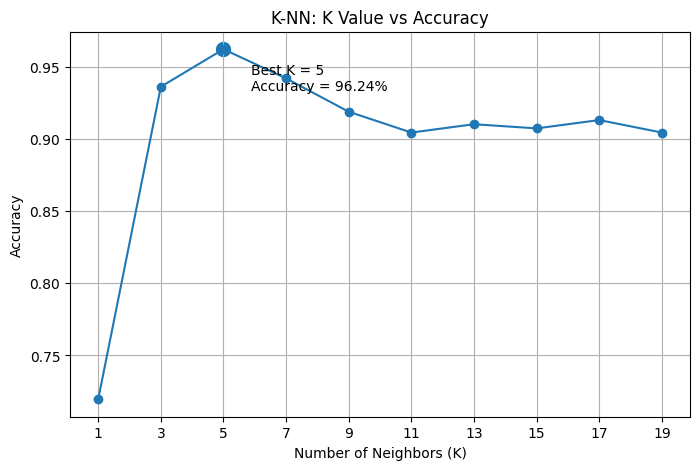

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K-NN: K Value vs Accuracy")
plt.xticks(k_values)
plt.grid(True)

# Highlight best K
plt.scatter(best_k, best_accuracy, s=100)
plt.annotate(
    f"Best K = {best_k}\nAccuracy = {best_accuracy:.2%}",
    (best_k, best_accuracy),
    xytext=(20, -30),
    textcoords="offset points"
)

plt.show()

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

metrics = ['euclidean', 'manhattan', 'minkowski']

metric_results = {}

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    metric_results[metric] = accuracy

    print(f"{metric.capitalize():10s} --> Accuracy = {accuracy:.4f}")

best_metric = max(metric_results, key=metric_results.get)

print("\nBest Distance Metric:", best_metric)
print("Best Accuracy:", metric_results[best_metric])

Euclidean  --> Accuracy = 0.9624
Manhattan  --> Accuracy = 0.9624
Minkowski  --> Accuracy = 0.9624

Best Distance Metric: euclidean
Best Accuracy: 0.9624277456647399


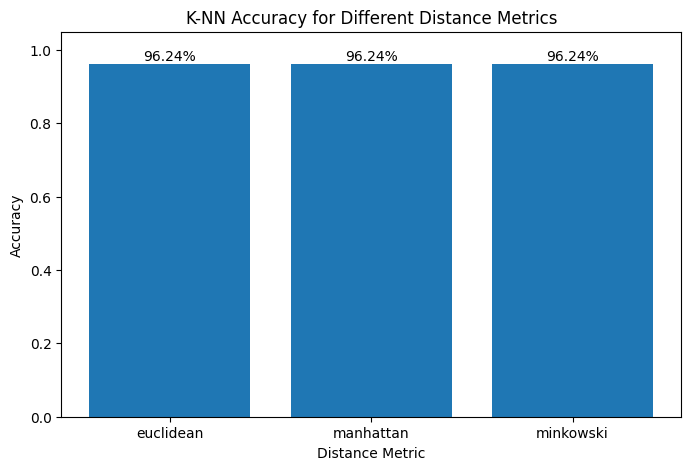

In [15]:
import matplotlib.pyplot as plt

metric_names = list(metric_results.keys())
metric_accuracies = list(metric_results.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(metric_names, metric_accuracies)

plt.xlabel("Distance Metric")
plt.ylabel("Accuracy")
plt.title("K-NN Accuracy for Different Distance Metrics")
plt.ylim(0, 1.05)

# Display accuracy on top of bars
for bar, accuracy in zip(bars, metric_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.01,
        f"{accuracy:.2%}",
        ha='center'
    )

plt.show()

===== FINAL K-NN MODEL =====
Accuracy  : 0.9624
Precision : 0.9628
Recall    : 0.9624
F1-Score  : 0.9603

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         acc       0.89      0.96      0.93        77
        good       0.89      0.57      0.70        14
       unacc       0.99      1.00      0.99       242
       vgood       1.00      0.77      0.87        13

    accuracy                           0.96       346
   macro avg       0.94      0.82      0.87       346
weighted avg       0.96      0.96      0.96       346



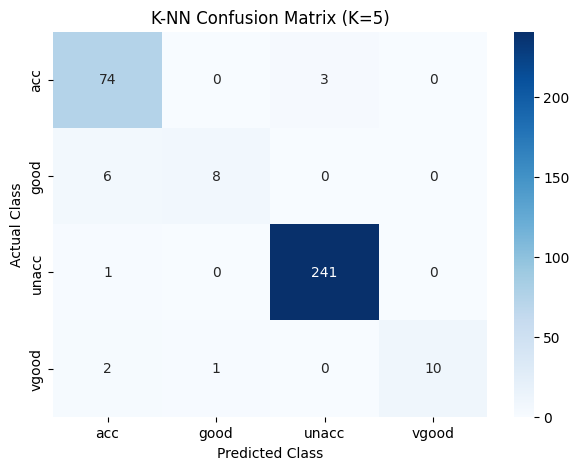

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Final K-NN model
final_knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

final_knn.fit(X_train_scaled, y_train)

# Prediction
y_pred_final = final_knn.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, average='weighted')
recall = recall_score(y_test, y_pred_final, average='weighted')
f1 = f1_score(y_test, y_pred_final, average='weighted')

print("===== FINAL K-NN MODEL =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=encoders['class'].classes_
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoders['class'].classes_,
    yticklabels=encoders['class'].classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("K-NN Confusion Matrix (K=5)")
plt.show()

In [20]:
# Take user input
buying = input("Buying price (vhigh/high/med/low): ")
maint = input("Maintenance price (vhigh/high/med/low): ")
doors = input("Number of doors (2/3/4/5more): ")
persons = input("Persons capacity (2/4/more): ")
lug_boot = input("Luggage boot size (small/med/big): ")
safety = input("Safety (low/med/high): ")

# Create input DataFrame
user_data = pd.DataFrame([[
    buying, maint, doors, persons, lug_boot, safety
]], columns=[
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety'
])

try:
    # Encode using training encoders
    for col in user_data.columns:
        user_data[col] = encoders[col].transform(user_data[col])

    # Scale input
    user_data_scaled = scaler.transform(user_data)

    # Predict
    prediction = final_knn.predict(user_data_scaled)

    # Convert prediction back to original class
    predicted_class = encoders['class'].inverse_transform(prediction)

    print("\n================================")
    print("Predicted Car Evaluation:", predicted_class[0])
    print("================================")

except ValueError as e:
    print("\nInvalid input!")
    print("Please enter values exactly as shown in the prompts.")
    print("Error:", e)

Buying price (vhigh/high/med/low): vhigh
Maintenance price (vhigh/high/med/low): vhigh
Number of doors (2/3/4/5more): 2
Persons capacity (2/4/more): 2
Luggage boot size (small/med/big): small
Safety (low/med/high): low

Predicted Car Evaluation: unacc
